# TP5 — Digits Dataset et Dataset Synthétique

Ce notebook suit le TP N°5 :
1. Charger et explorer le dataset réel `digits`.
2. Générer et utiliser un dataset synthétique avec `make_classification`.

In [7]:
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1) Dataset réel : Digits

In [8]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print('Digits - X shape:', X_digits.shape)
print('Digits - y shape:', y_digits.shape)
print('Nombre de classes:', len(np.unique(y_digits)))
print('Classes:', np.unique(y_digits))

Digits - X shape: (1797, 64)
Digits - y shape: (1797,)
Nombre de classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


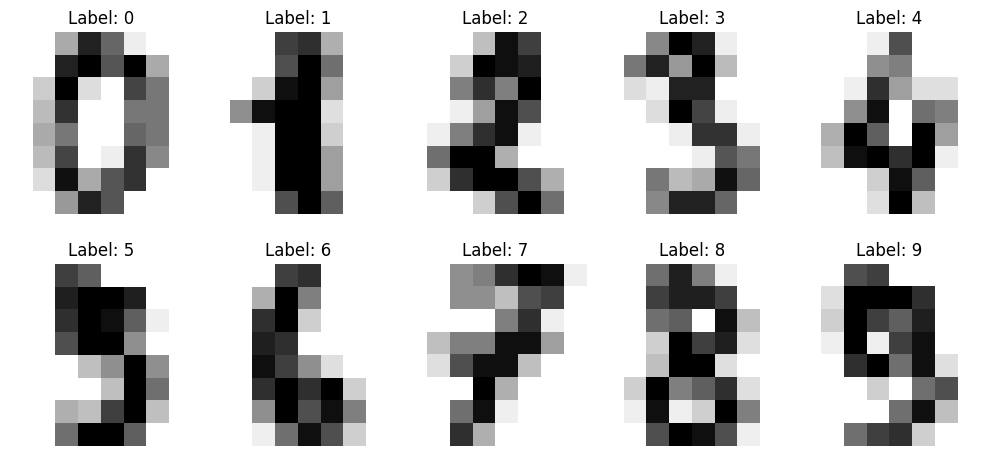

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Label: {y_digits[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42
)
knn_digits = KNeighborsClassifier(n_neighbors=5)
knn_digits.fit(X_train_d, y_train_d)
y_pred_d = knn_digits.predict(X_test_d)
acc_digits = accuracy_score(y_test_d, y_pred_d)
print(f'Accuracy KNN sur digits: {acc_digits:.4f}')

Accuracy KNN sur digits: 0.9926


## 2) Dataset synthétique : make_classification

In [11]:
X_syn, y_syn = make_classification(
    n_samples=1000,
    n_features=50,
    n_informative=5,
    n_redundant=10,
    n_classes=2,
    random_state=42
)

print('Synthetic - X shape:', X_syn.shape)
print('Synthetic - y shape:', y_syn.shape)
print('Classes synthétiques:', np.unique(y_syn))

Synthetic - X shape: (1000, 50)
Synthetic - y shape: (1000,)
Classes synthétiques: [0 1]


In [12]:
df_syn = pd.DataFrame(X_syn, columns=[f'f{i}' for i in range(X_syn.shape[1])])
df_syn['target'] = y_syn
display(df_syn.head())
print('Répartition des classes:')
print(df_syn['target'].value_counts().sort_index())

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f41,f42,f43,f44,f45,f46,f47,f48,f49,target
0,-0.486272,-0.846731,-0.775656,1.885177,1.297464,0.011965,-2.308984,-0.346801,0.320596,1.161990,...,-0.934564,-1.063711,-1.290583,0.399046,1.166956,-1.025989,-0.460598,-0.049675,-1.213305,1
1,-0.107344,1.017606,-0.985729,-2.039247,2.579122,2.226095,-1.805847,1.094946,-1.809880,0.382668,...,1.567688,1.356018,-0.597565,1.482873,1.791512,-0.185131,-0.805406,0.327947,1.334033,0
2,-0.418370,0.964677,-3.133356,-0.297532,0.496723,-2.886565,-0.613511,-0.058161,-1.055313,-0.412700,...,-0.235000,0.336576,0.614553,-1.721506,-0.167817,-1.665521,0.491986,-0.175428,0.338025,1
3,0.184467,0.286552,-2.970289,3.473889,3.203624,-0.033962,-1.697831,1.260469,-0.554164,-0.835777,...,-4.080246,-1.435099,-0.452328,-0.415254,0.962223,-2.001574,-0.065985,-0.308203,1.780493,1
4,-0.476398,-0.135526,1.306253,-4.911718,0.514971,3.366542,-1.125265,0.159608,0.662563,-0.657212,...,4.605669,-0.834429,1.538330,0.141305,1.579089,-1.072058,0.815943,0.055043,0.738823,0


Répartition des classes:
target
0    499
1    501
Name: count, dtype: int64


In [13]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)
knn_syn = KNeighborsClassifier(n_neighbors=5)
knn_syn.fit(X_train_s, y_train_s)
y_pred_s = knn_syn.predict(X_test_s)
acc_syn = accuracy_score(y_test_s, y_pred_s)
print(f'Accuracy KNN sur dataset synthétique: {acc_syn:.4f}')

Accuracy KNN sur dataset synthétique: 0.9167


## 3) Feature Selection avec PSO — Fonction objectif

Selon le TP :
- Une solution `x` est un vecteur réel dans `[0,1]` de taille `D`.
- On sélectionne les `SF` indices ayant les plus grandes valeurs de `x`.
- Fonction objectif : `f(x) = α * (1 - Accuracy) + (1 - α) * (SF / D)`.

In [14]:
def get_selected_indices(solution, sf):
    solution = np.asarray(solution, dtype=float)
    # Tri déterministe: d'abord valeur décroissante, puis index croissant
    ranked = sorted(enumerate(solution), key=lambda t: (-t[1], t[0]))
    selected = [idx for idx, _ in ranked[:sf]]
    return np.array(sorted(selected), dtype=int)


def objective_function(solution, X, y, sf, alpha=0.9, test_size=0.3, random_state=42, n_neighbors=5):
    D = X.shape[1]
    sf = int(sf)
    if sf <= 0 or sf > D:
        raise ValueError(f"sf must be in [1, {D}]")

    solution = np.asarray(solution, dtype=float)
    if solution.shape[0] != D:
        raise ValueError(f"solution length must be {D}, got {solution.shape[0]}")

    selected_indices = get_selected_indices(solution, sf)
    X_selected = X[:, selected_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=test_size, random_state=random_state
    )

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = 1 - accuracy
    f2 = sf / D
    fitness = alpha * f1 + (1 - alpha) * f2

    return {
        "fitness": fitness,
        "accuracy": accuracy,
        "selected_features": selected_indices,
        "solution": solution,
        "f1": f1,
        "f2": f2,
        "alpha": alpha,
    }


def display_like_interface(result):
    solution_text = " | ".join([f"{v:.2f}" for v in result["solution"]])
    indices_text = " | ".join(map(str, result["selected_features"]))
    print("Solution:")
    print(solution_text)
    print("\nIndices of selected features:")
    print(indices_text)
    print(
        f"\nFitness — {result['fitness']:.4f}, Accuracy — {result['accuracy']:.4f}, "
        f"Selected Features — {len(result['selected_features'])}"
    )


# Démo rapide random (comme dans l'interface)
np.random.seed(42)
solution_digits = np.random.rand(X_digits.shape[1])
result_digits = objective_function(solution_digits, X_digits, y_digits, sf=10, alpha=0.9)

print("DIGITS (random solution)")
display_like_interface(result_digits)

solution_syn = np.random.rand(X_syn.shape[1])
result_syn = objective_function(solution_syn, X_syn, y_syn, sf=5, alpha=0.9)

print("\nSYNTHETIC (random solution)")
display_like_interface(result_syn)

DIGITS (random solution)
Solution:
0.37 | 0.95 | 0.73 | 0.60 | 0.16 | 0.16 | 0.06 | 0.87 | 0.60 | 0.71 | 0.02 | 0.97 | 0.83 | 0.21 | 0.18 | 0.18 | 0.30 | 0.52 | 0.43 | 0.29 | 0.61 | 0.14 | 0.29 | 0.37 | 0.46 | 0.79 | 0.20 | 0.51 | 0.59 | 0.05 | 0.61 | 0.17 | 0.07 | 0.95 | 0.97 | 0.81 | 0.30 | 0.10 | 0.68 | 0.44 | 0.12 | 0.50 | 0.03 | 0.91 | 0.26 | 0.66 | 0.31 | 0.52 | 0.55 | 0.18 | 0.97 | 0.78 | 0.94 | 0.89 | 0.60 | 0.92 | 0.09 | 0.20 | 0.05 | 0.33 | 0.39 | 0.27 | 0.83 | 0.36

Indices of selected features:
1 | 7 | 11 | 33 | 34 | 43 | 50 | 52 | 53 | 55

Fitness — 0.2790, Accuracy — 0.7074, Selected Features — 10

SYNTHETIC (random solution)
Solution:
0.28 | 0.54 | 0.14 | 0.80 | 0.07 | 0.99 | 0.77 | 0.20 | 0.01 | 0.82 | 0.71 | 0.73 | 0.77 | 0.07 | 0.36 | 0.12 | 0.86 | 0.62 | 0.33 | 0.06 | 0.31 | 0.33 | 0.73 | 0.64 | 0.89 | 0.47 | 0.12 | 0.71 | 0.76 | 0.56 | 0.77 | 0.49 | 0.52 | 0.43 | 0.03 | 0.11 | 0.03 | 0.64 | 0.31 | 0.51 | 0.91 | 0.25 | 0.41 | 0.76 | 0.23 | 0.08 | 0.29 | 0.16 | 0.93 |

In [15]:
# === Tests demandés dans le PDF ===
alpha_case = 0.9

case1_solution = np.array([
    0.74, 0.56, 0.79, 0.92, 0.28, 0.13, 0.53, 0.80, 0.49, 0.91, 0.91, 0.88, 0.71, 0.96, 0.31, 0.30,
    0.01, 0.14, 0.36, 0.42, 0.53, 0.99, 0.73, 0.53, 0.84, 0.10, 0.34, 0.63, 0.02, 0.29, 0.46, 0.30,
    0.18, 0.21, 0.23, 0.78, 0.59, 0.50, 0.27, 0.30, 0.36, 0.99, 0.15, 0.60, 0.03, 0.37, 0.52, 0.12,
    0.32, 0.69, 0.48, 0.91, 0.45, 0.57, 0.46, 0.62, 0.68, 0.48, 0.27, 0.94, 0.47, 0.70, 0.12, 0.35
], dtype=float)

case2_solution = np.array([
    0.80, 0.70, 0.89, 0.55, 0.78, 0.63, 0.36, 0.83, 0.18, 0.94, 0.31, 0.22, 0.53, 0.69, 0.41, 0.52,
    0.55, 0.23, 0.74, 0.73, 0.82, 0.45, 0.35, 0.67, 0.12, 0.62, 0.38, 0.93, 0.04, 0.54, 0.72, 0.09,
    0.23, 0.36, 0.21, 0.56, 0.07, 0.37, 0.60, 0.31, 0.73, 0.24, 0.71, 0.46, 0.94, 0.17, 0.00, 0.65,
    0.48, 0.19, 0.34, 0.15, 0.42, 0.52, 0.31, 0.29, 0.34, 0.99, 0.59, 0.76, 0.32, 0.55, 0.16, 0.39
], dtype=float)

expected_case1_idx = np.array([0, 1, 2, 3, 7, 9, 10, 11, 12, 13, 21, 22, 24, 27, 35, 36, 41, 43, 49, 51, 53, 55, 56, 59, 61])
expected_case2_idx = np.array([0, 2, 4, 7, 9, 20, 27, 44, 57, 59])

# Ces cas sont donnés pour D=64 => dataset digits
res_case1 = objective_function(case1_solution, X_digits, y_digits, sf=25, alpha=alpha_case)
res_case2 = objective_function(case2_solution, X_digits, y_digits, sf=10, alpha=alpha_case)

print("CASE 1 — Selected 25, Alpha 0.9")
print("Indices calculés:", res_case1["selected_features"])
print("Indices attendus:", expected_case1_idx)
print("Match:", np.array_equal(res_case1["selected_features"], expected_case1_idx))
display_like_interface(res_case1)

print("\n" + "=" * 90 + "\n")

print("CASE 2 — Selected 10, Alpha 0.9")
print("Indices calculés:", res_case2["selected_features"])
print("Indices attendus:", expected_case2_idx)
print("Match:", np.array_equal(res_case2["selected_features"], expected_case2_idx))
display_like_interface(res_case2)

CASE 1 — Selected 25, Alpha 0.9
Indices calculés: [ 0  1  2  3  7  9 10 11 12 13 21 22 24 27 35 36 41 43 49 51 53 55 56 59
 61]
Indices attendus: [ 0  1  2  3  7  9 10 11 12 13 21 22 24 27 35 36 41 43 49 51 53 55 56 59
 61]
Match: True
Solution:
0.74 | 0.56 | 0.79 | 0.92 | 0.28 | 0.13 | 0.53 | 0.80 | 0.49 | 0.91 | 0.91 | 0.88 | 0.71 | 0.96 | 0.31 | 0.30 | 0.01 | 0.14 | 0.36 | 0.42 | 0.53 | 0.99 | 0.73 | 0.53 | 0.84 | 0.10 | 0.34 | 0.63 | 0.02 | 0.29 | 0.46 | 0.30 | 0.18 | 0.21 | 0.23 | 0.78 | 0.59 | 0.50 | 0.27 | 0.30 | 0.36 | 0.99 | 0.15 | 0.60 | 0.03 | 0.37 | 0.52 | 0.12 | 0.32 | 0.69 | 0.48 | 0.91 | 0.45 | 0.57 | 0.46 | 0.62 | 0.68 | 0.48 | 0.27 | 0.94 | 0.47 | 0.70 | 0.12 | 0.35

Indices of selected features:
0 | 1 | 2 | 3 | 7 | 9 | 10 | 11 | 12 | 13 | 21 | 22 | 24 | 27 | 35 | 36 | 41 | 43 | 49 | 51 | 53 | 55 | 56 | 59 | 61

Fitness — 0.0957, Accuracy — 0.9370, Selected Features — 25


CASE 2 — Selected 10, Alpha 0.9
Indices calculés: [ 0  2  4  7  9 20 27 44 57 59]
Indices attendu

## Résumé
- `digits` : dataset réel (1797 images, 64 features, 10 classes).
- `synthetic` : dataset artificiel contrôlé (1000 instances, 50 features).
- Les deux datasets sont prêts pour la suite du TP (feature selection avec PSO).